In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider, fixed

n_cooldown = 13
date = '2026-06-15'


initialise_or_create_database_at(f"./{date}_SNSPD{n_cooldown}.db")
import snspd
params = snspd.snspd(f'snspd{n_cooldown}.yaml')

# Set up experiment
exp_name = f'SNSPD{n_cooldown}_{date}'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260615-28200-qcodes.log
Experiment loaded. Last ID no: 1


In [108]:
import importlib
importlib.reload(snspd)
params = snspd.snspd(f'snspd{n_cooldown}.yaml')

In [26]:
import inspect

print(inspect.signature(params.plot_critical_current))

(ID, ratio=False)


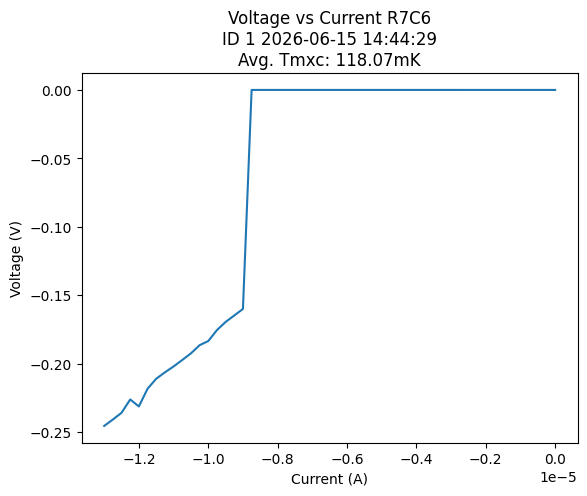

In [33]:
params.plot_critical_current(ID=1)

A way to get traces without splitting between IDs 

In [8]:
load_by_id(1).get_parameter_data().keys()

dict_keys(['MC_temp', 'dmm_volt'])

# To do 

* Make the device the input to every function
* Modularise counting function 

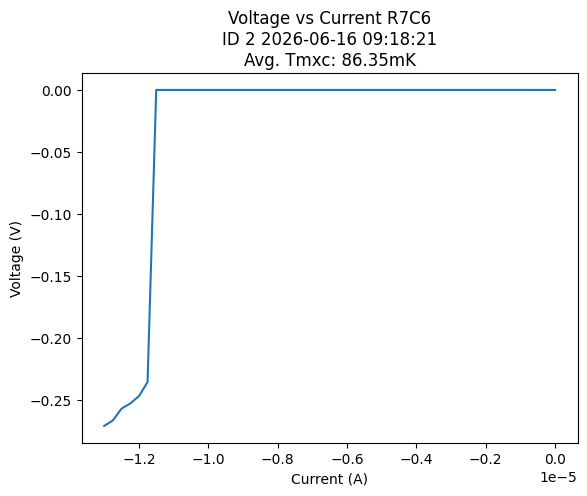

In [43]:
params.plot_critical_current(ID=2)

In [42]:
params.args(params.trace_vs_current)

(device, MS, dmm, yoko, trigger, v_scale, wait=120, currents=None, station=None)


In [74]:
np.isnan(data['yoko_current']['yoko_current'])

array([False, False, False, ...,  True,  True,  True], shape=(99375,))

In [77]:
int(data['h_samples']['h_samples'][0])

array([1875., 1875., 1875., ...,   nan,   nan,   nan], shape=(99375,))

In [78]:
99375/1875

53.0

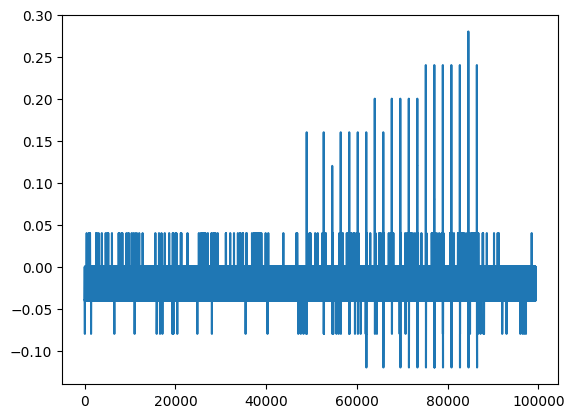

In [80]:
data = load_by_id(4).get_parameter_data()
plt.plot(data['trace']['trace'])
rows = len(data['yoko_current']['yoko_current'][~np.isnan(data['yoko_current']['yoko_current'])])
cols = int(data['h_samples']['h_samples'][0])
trace = np.reshape(data['trace']['trace'], (rows, cols))
# in the xarray thing the coordinates would be currents and time_axis and then everything else would be metadata/attributes

In [113]:
from scipy.signal import find_peaks
data = load_by_id(4).get_parameter_data()
trace = data['trace']['trace']


def plot_traces(idx, ID):
    data = load_by_id(ID).get_parameter_data()
    currents = data['yoko_current']['yoko_current']
    rows = len(currents[~np.isnan(currents)])
    cols = int(data['h_samples']['h_samples'][0])
    trigger = data['trigger']['trigger'][idx]
    v_scale = data['v_scale']['v_scale'][idx]
    trace = np.reshape(data['trace']['trace'], (rows, cols))[idx]
    time_axis = np.reshape(data['time_axis']['time_axis'], (rows, cols))[idx]
    current = currents[idx]
    # plotting the calibraiton parameters form last cooldown on these results 
    threshold1 = params.device_line_2['count_calibration']['threshold1'][idx]
    threshold2 = params.device_line_2['count_calibration']['threshold2'][idx]
    
    peaks, _ = find_peaks(trace, height=float(trigger), distance=len(trace))
    fig, ax = plt.subplots(1,1)
    ax.plot(time_axis, trace)
    ax.set_title(f'Current: {current} V_scale {v_scale}V Res {1e3*v_scale/25}mV')
    ax.plot(time_axis[peaks],trace[peaks], 'ro', label=f'Peak {trace[peaks]*1e3}mV')
    ax.axhline(trigger, label=f'Trigger {trigger*1e3}mV')
    ax.axhline(threshold1, label=f'T1 {threshold1*1e3}mV', color='r')
    ax.axhline(threshold2, label=f'T1 {threshold2*1e3}mV', color='m')
    ax.legend()

ID = 4                  
interact(plot_traces, idx=IntSlider(min=0, max=53, step=1, value=0,
                                continuous_update=False), ID=fixed(ID))

interactive(children=(IntSlider(value=0, continuous_update=False, description='idx', max=53), Output()), _dom_…

<function __main__.plot_traces(idx, ID)>

In [109]:
params.device_line_2.keys()

dict_keys(['name', 'currents', 'count_calibration', 'counts_axes', 'IDs'])

In [67]:
rows = len(data['yoko_current']['yoko_current'][~np.isnan(data['yoko_current']['yoko_current'])])
cols = int(data['h_samples']['h_samples'][0])
trace = np.reshape(data['trace']['trace'], (rows, cols))

array([ 0.00e+00, -2.50e-07, -5.00e-07, -7.50e-07, -1.00e-06, -1.25e-06,
       -1.50e-06, -1.75e-06, -2.00e-06, -2.25e-06, -2.50e-06, -2.75e-06,
       -3.00e-06, -3.25e-06, -3.50e-06, -3.75e-06, -4.00e-06, -4.25e-06,
       -4.50e-06, -4.75e-06, -5.00e-06, -5.25e-06, -5.50e-06, -5.75e-06,
       -6.00e-06, -6.25e-06, -6.50e-06, -6.75e-06, -7.00e-06, -7.25e-06,
       -7.50e-06, -7.75e-06, -8.00e-06, -8.25e-06, -8.50e-06, -8.75e-06,
       -9.00e-06, -9.25e-06, -9.50e-06])

In [53]:
print(data['trigger']['trigger'][:len(params.device_line_2['currents'])])

[0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12
 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12
 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12
 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]


In [54]:
print(data['v_scale']['v_scale'][:len(params.device_line_2['currents'])])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]


In [55]:
MS.channels[0].vertical_scale(150e-3)

NameError: name 'MS' is not defined

In [57]:
data = load_by_id(5).get_parameter_data()
print(data['v_scale']['v_scale'][:len(params.device_line_2['currents'])])
print(data['trigger']['trigger'][:len(params.device_line_2['currents'])])

[0.15 0.15  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
[0.048 0.102   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan]


These are correct. 

In [60]:
data = load_by_id(10).get_parameter_data()

In [63]:
data['CR1']['yoko_current']

array([ 0.00e+00, -2.50e-07, -5.00e-07, -7.50e-07, -1.00e-06, -1.25e-06,
       -1.50e-06, -1.75e-06, -2.00e-06, -2.25e-06, -2.50e-06, -2.75e-06,
       -3.00e-06, -3.25e-06, -3.50e-06, -3.75e-06, -4.00e-06, -4.25e-06,
       -4.50e-06, -4.75e-06, -5.00e-06, -5.25e-06, -5.50e-06, -5.75e-06,
       -6.00e-06, -6.25e-06, -6.50e-06, -6.75e-06, -7.00e-06, -7.25e-06,
       -7.50e-06, -7.75e-06, -8.00e-06, -8.25e-06, -8.50e-06, -8.75e-06,
       -9.00e-06, -9.25e-06, -9.50e-06])

In [64]:
data['threshold1']['threshold1']

array([0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192,
       0.024 , 0.0288, 0.0336, 0.0384, 0.0432, 0.048 , 0.0576, 0.0624,
       0.0624, 0.0672, 0.0768, 0.0816, 0.0816, 0.0912, 0.096 , 0.1008,
       0.1008, 0.1104, 0.1152, 0.12  , 0.1248, 0.1296, 0.1344, 0.144 ,
       0.144 , 0.1536, 0.1584, 0.1632, 0.1728, 0.1728, 0.1776,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
      

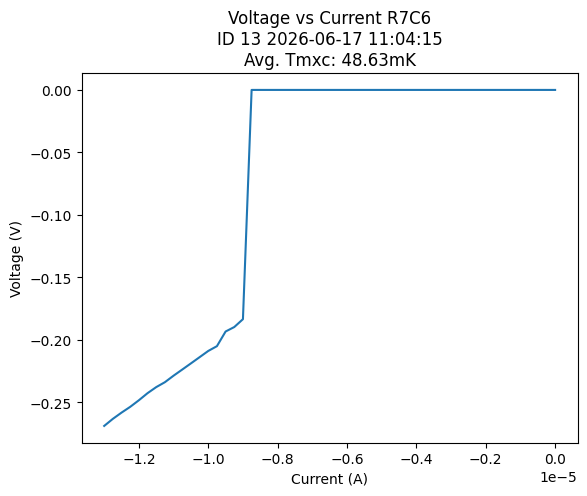

In [196]:
params.plot_critical_current(ID=13)

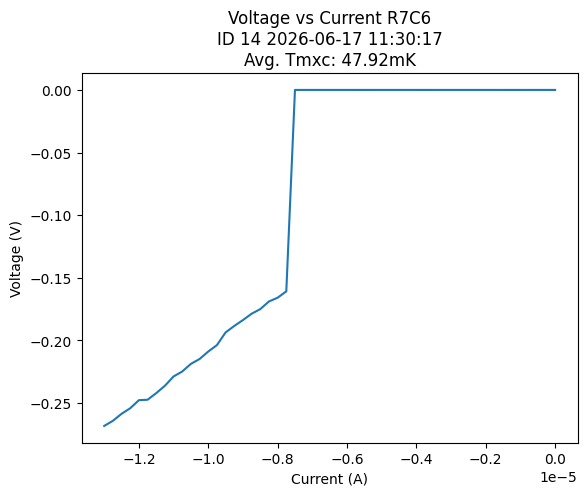

In [270]:
params.plot_critical_current(14)

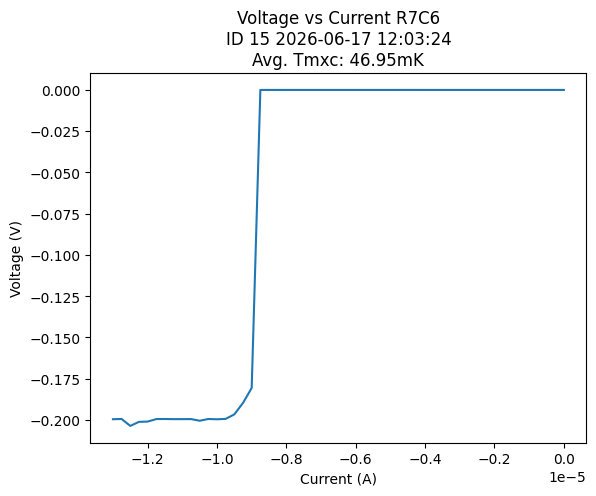

In [271]:
params.plot_critical_current(15)

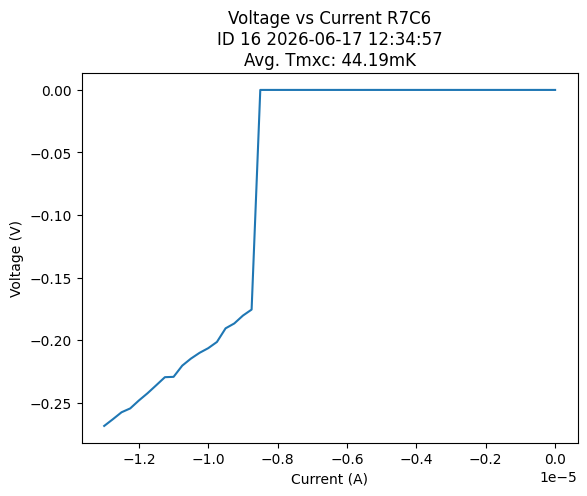

In [272]:
params.plot_critical_current(16)

([<Axes: title={'center': 'Run #24, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

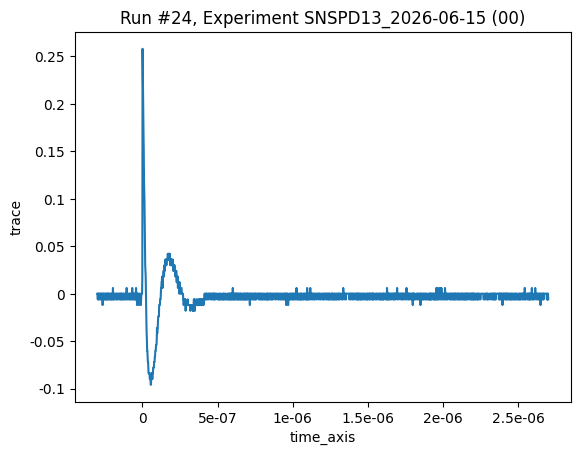

In [274]:
plot_by_id(24) # No resistor connected 

([<Axes: title={'center': 'Run #25, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

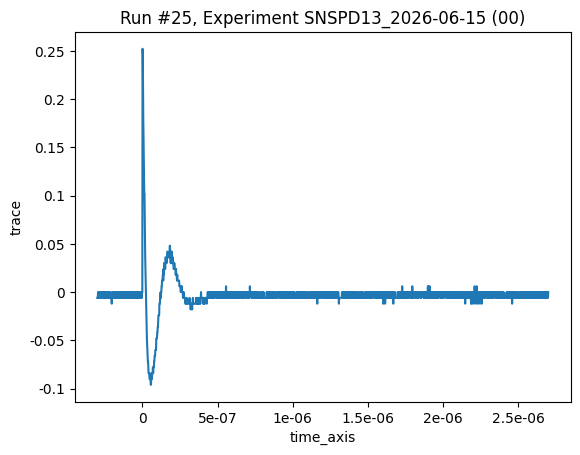

In [160]:
plot_by_id(25)

In [312]:
data = load_by_id(25).get_parameter_data()
data['yoko_current']['yoko_current']

array([-1.1e-05])

([<Axes: title={'center': 'Run #26, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

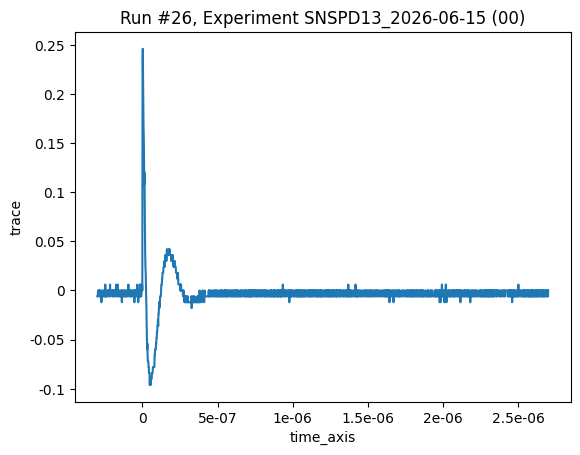

In [161]:
plot_by_id(26)

([<Axes: title={'center': 'Run #27, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

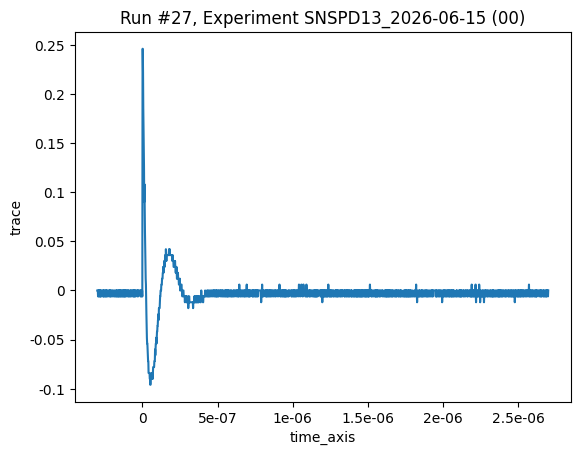

In [162]:
plot_by_id(27)

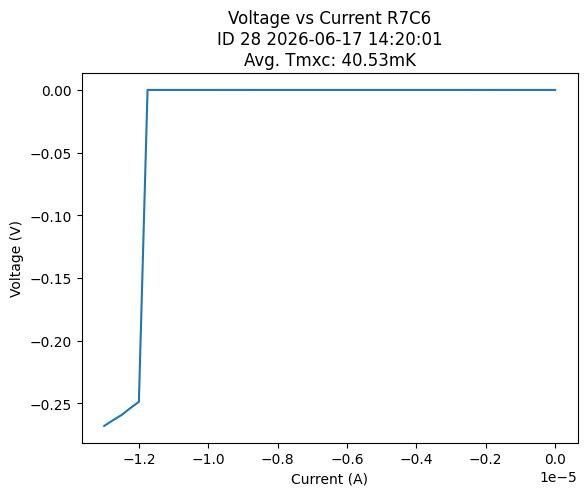

In [197]:
params.plot_critical_current(28)

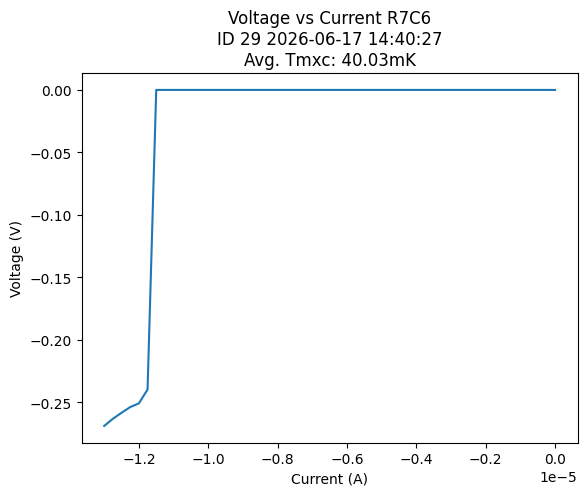

In [275]:
params.plot_critical_current(29)

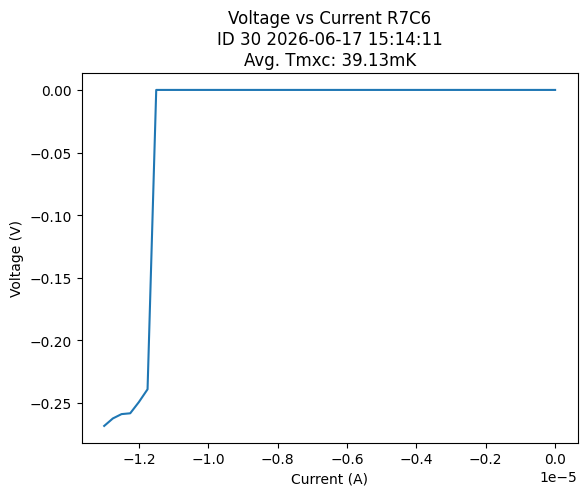

In [276]:
params.plot_critical_current(30)

No bias resistor connected. Goal is to run current sweep with positive currents to observe whether there is an offset. Checking thermometry on fridge (17/6 6:38pm) indicates that the amplifiers are still on. 

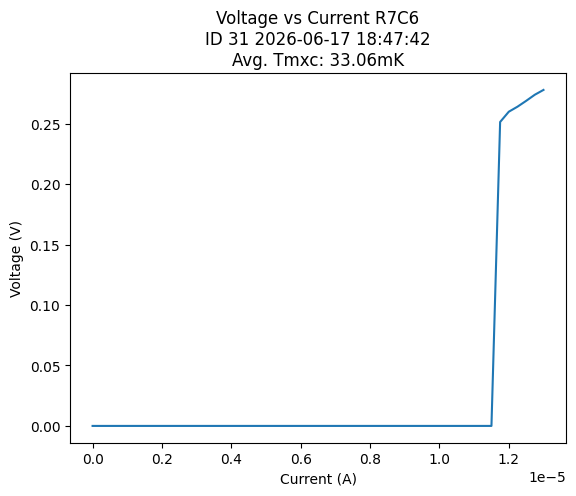

In [265]:
params.plot_critical_current(31)

To do:
1. Lower amplifier power current sweep
2. Turn off amplifiers. Wait for power to go down, then sweep positive currents again. Or in the meantime of 1. look for the old trace with positive currents.
3. \4K amplifier power supply set to 1V output, reading 0.01A. 11:53am.

4K amplifier power supply set to 1V output, reading 0.01A. 11:53am. ID 32

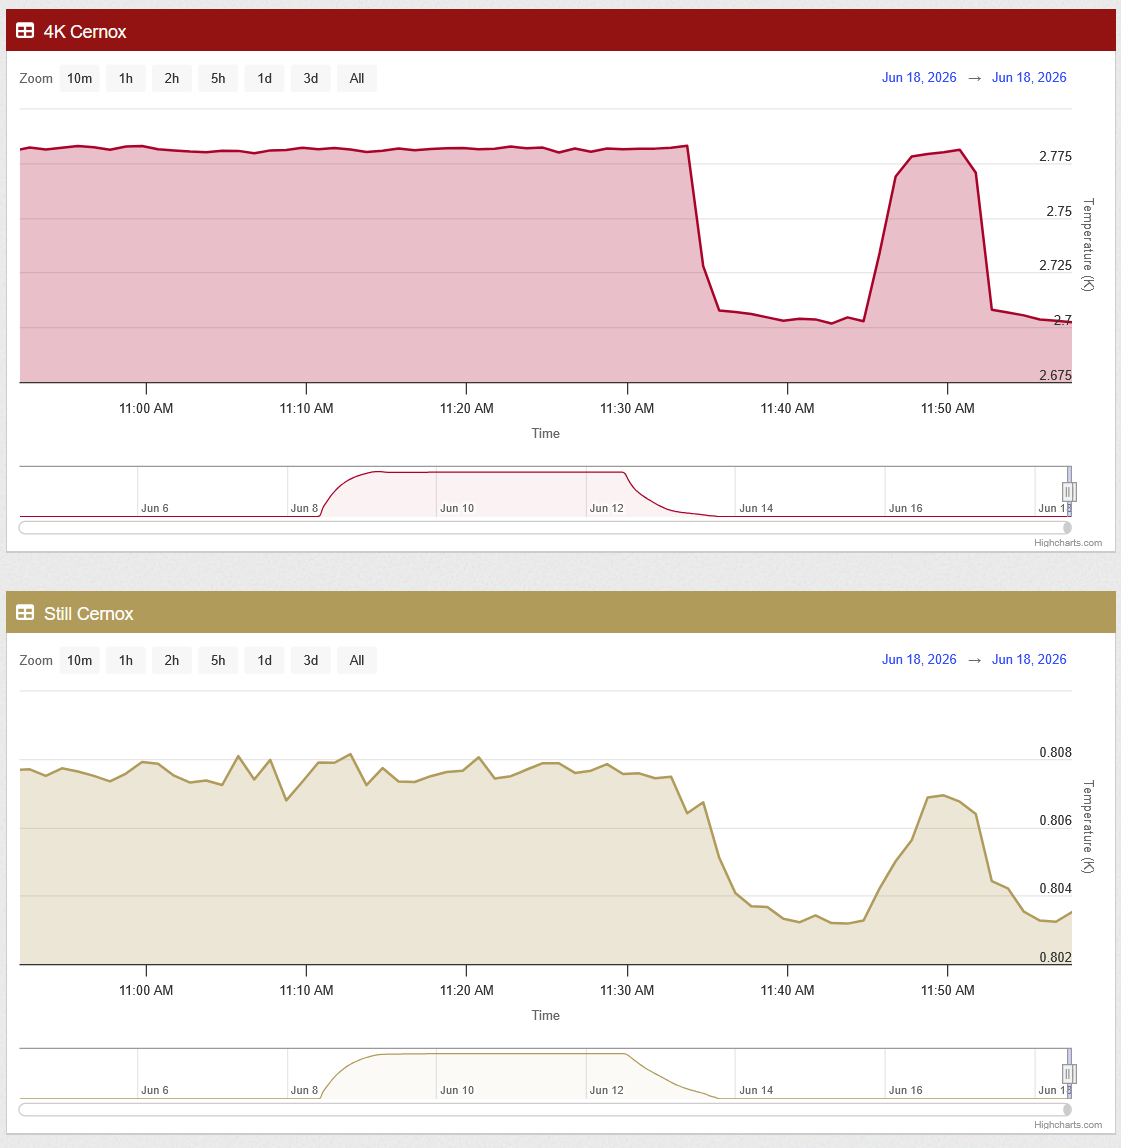

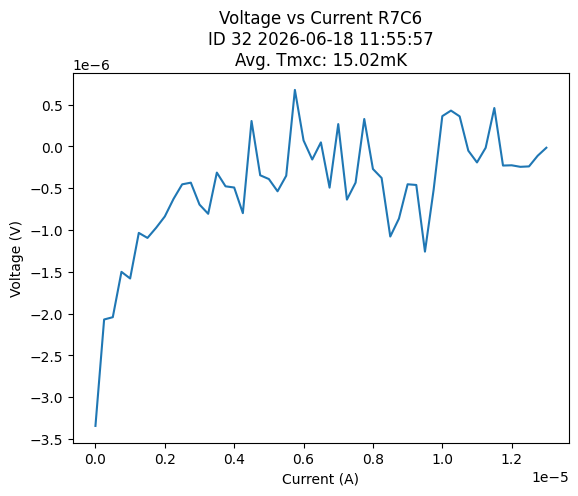

In [277]:
params.plot_critical_current(32)

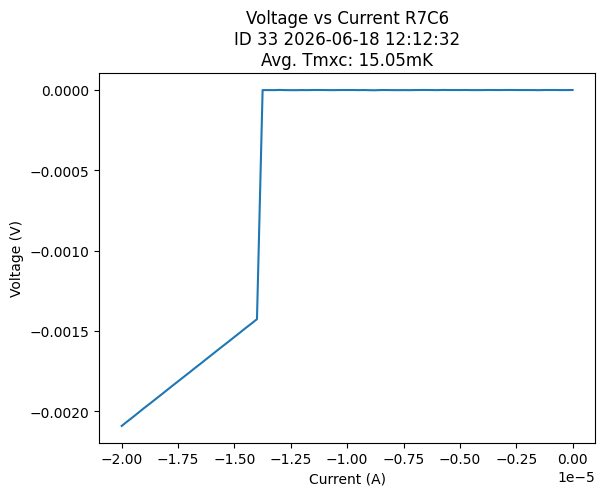

In [267]:
params.plot_critical_current(33)

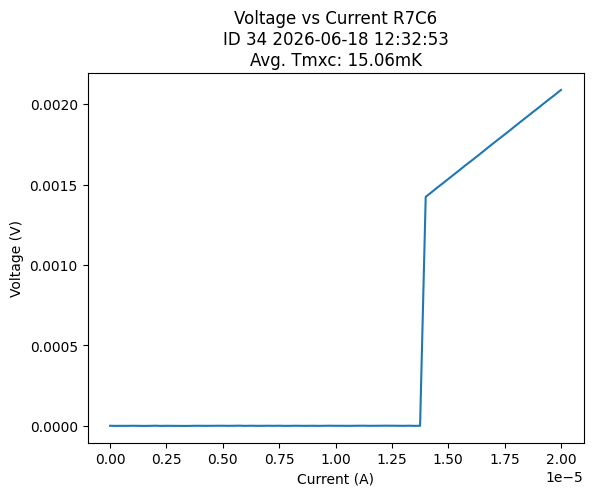

In [268]:
params.plot_critical_current(34)

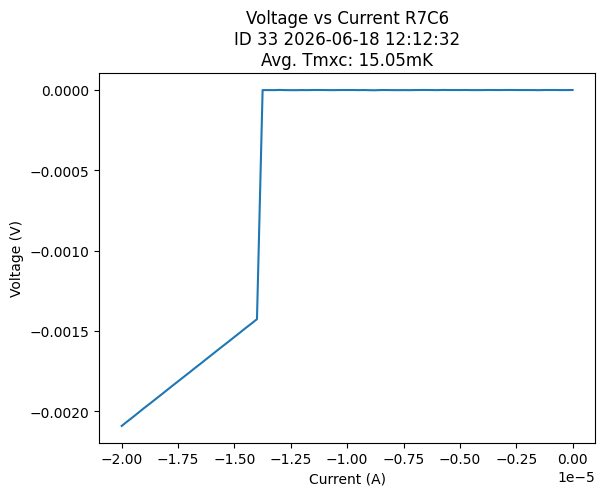

In [185]:
params.plot_critical_current(ID=33)

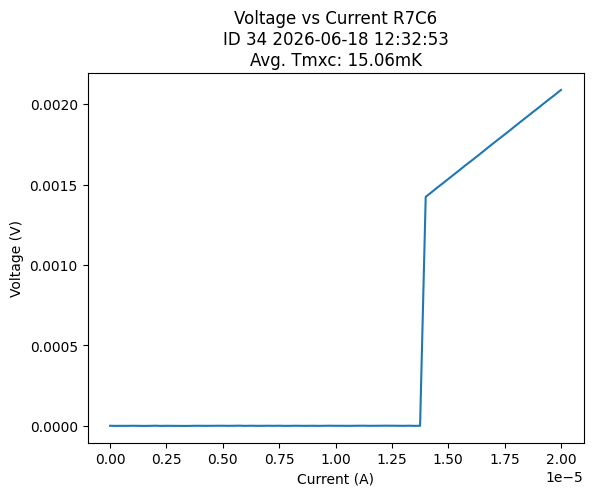

In [184]:
params.plot_critical_current(ID=34)

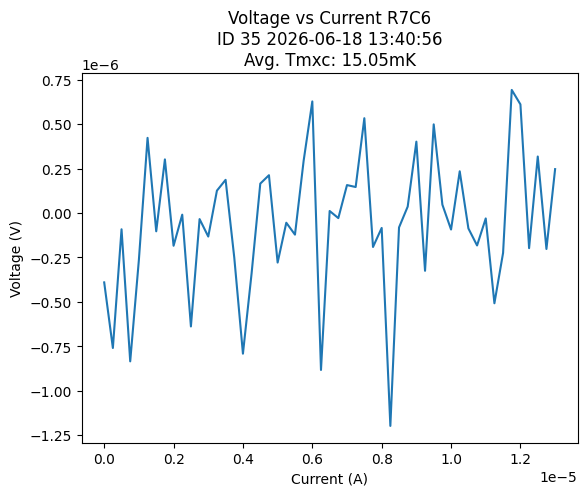

In [190]:
params.plot_critical_current(ID=35)

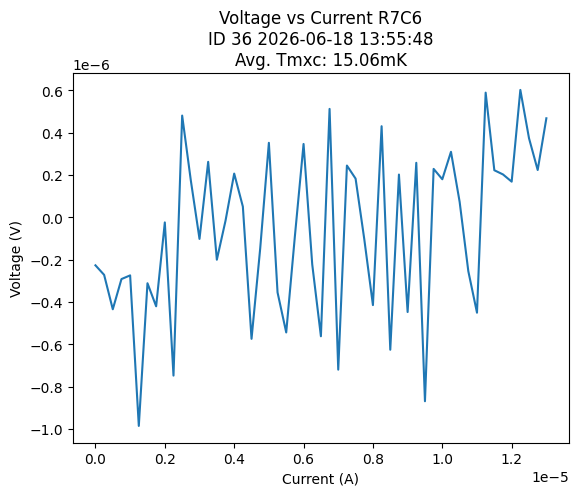

In [188]:
params.plot_critical_current(ID=36)

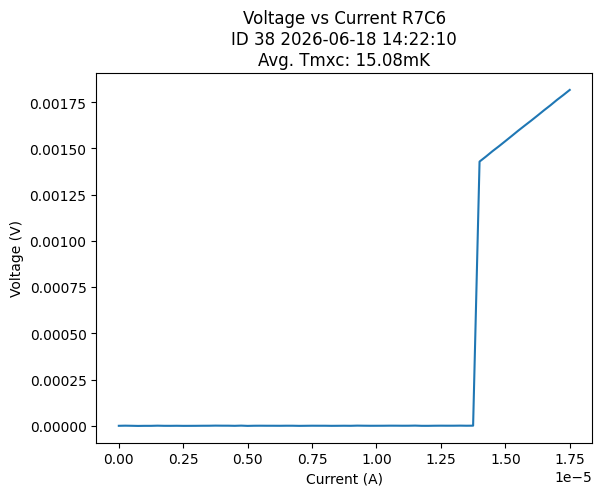

In [194]:
params.plot_critical_current(ID=38)

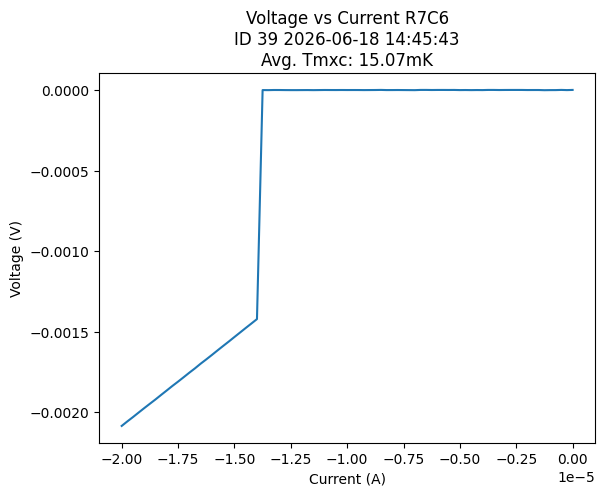

In [195]:
params.plot_critical_current(ID=39)

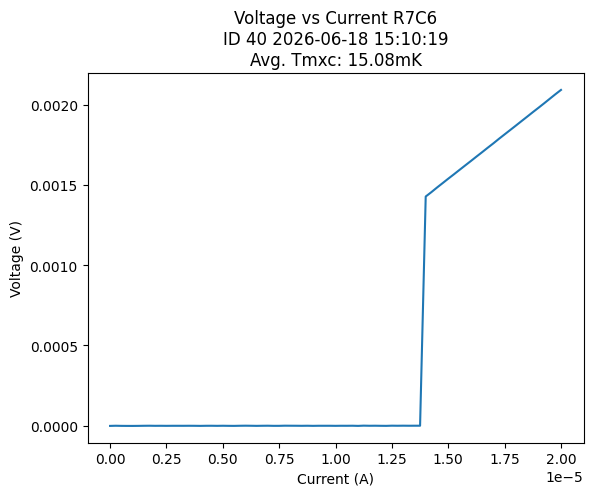

In [198]:
params.plot_critical_current(ID=40)

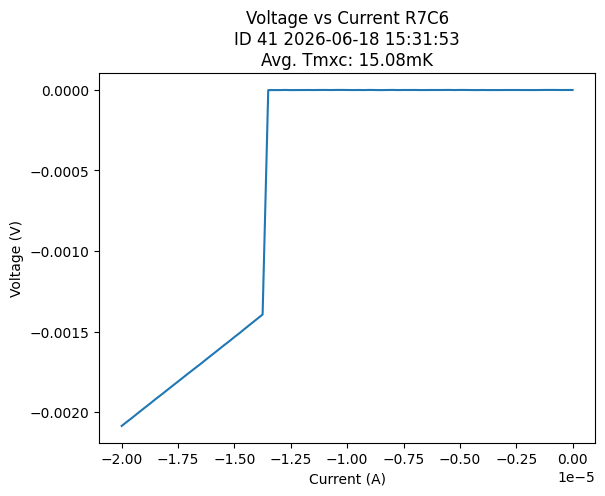

In [199]:
params.plot_critical_current(ID=41)

ID 46: Measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers on (4K amplifier power supply set to 2.5) 

([<Axes: title={'center': 'Run #48, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='Voltage (V)', ylabel='Voltage (mV)'>],
 [None])

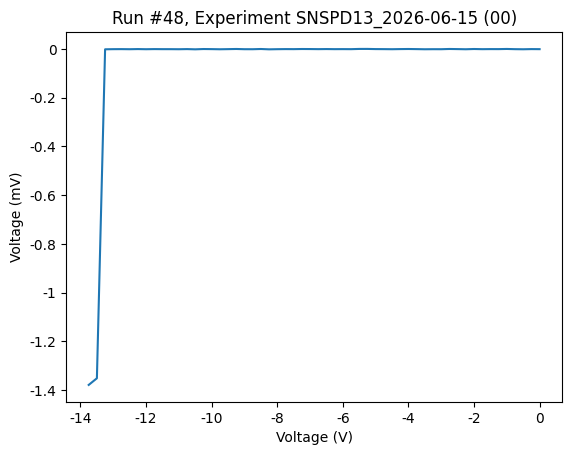

In [202]:
plot_by_id(48)

ID 49: Measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers off. 
Increased to 16V to allow for resistance to be obvious

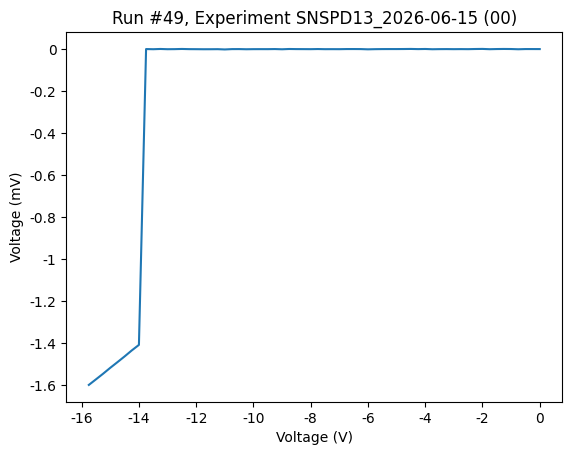

In [285]:
plot_by_id(49)
ID=49
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()

In [286]:
timestamp

'2026-06-19 12:17:22'

ID 49: Measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers off. 
Increased to 16V to allow for resistance to be obvious

([<Axes: title={'center': 'Run #50, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='Voltage (V)', ylabel='Voltage (mV)'>],
 [None])

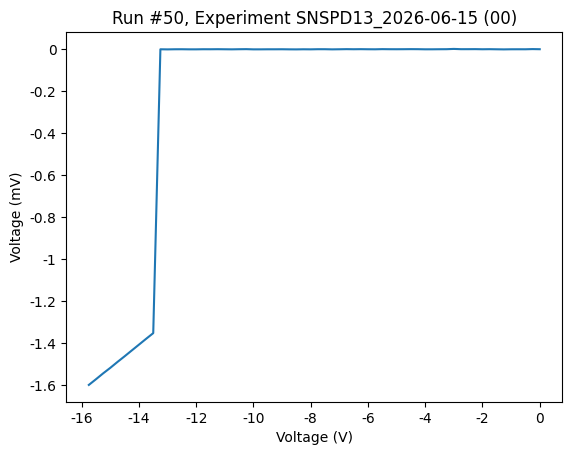

In [284]:
plot_by_id(50)

([<Axes: title={'center': 'Run #53, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

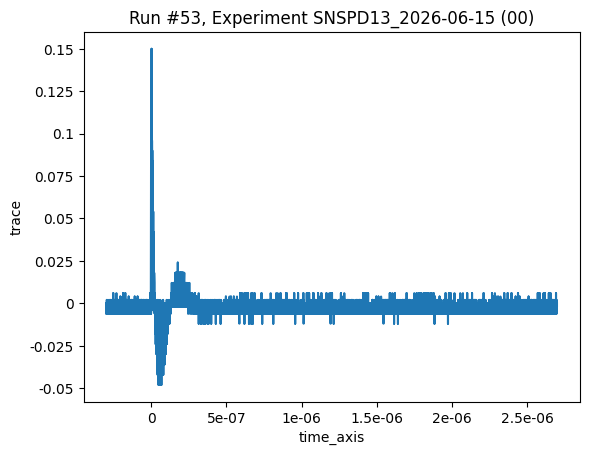

In [205]:
plot_by_id(53)

([<Axes: title={'center': 'Run #53, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

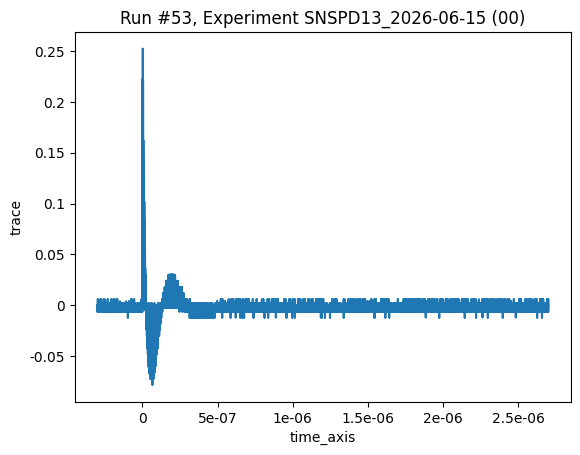

In [206]:
plot_by_id(53)

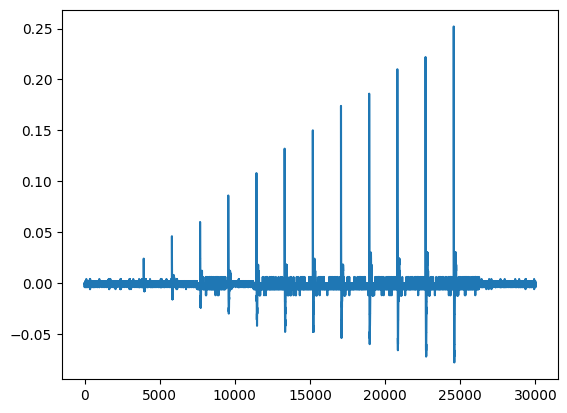

In [304]:
data = load_by_id(53).get_parameter_data()
trace = data['trace']['trace']
plt.plot(trace)

In [325]:
def process_traces(ID, mult1, mult2):
    from scipy.signal import find_peaks
    if (mult1 or mult2) > 1: 
        raise Exception('Multipliers must be between 1 and 0')
    data = load_by_id(ID).get_parameter_data()
    trace_raw = data['trace']['trace']
    time_axis_raw = data['time_axis']['time_axis']
    cols = int(data['h_samples']['h_samples'][0])
    voltage = data['yoko_voltage']['yoko_voltage'][~np.isnan(data['yoko_voltage']['yoko_voltage'])]
    v_peak = data['v_peak']['v_peak'][~np.isnan(data['v_peak']['v_peak'])]
    trigger = data['trigger']['trigger'][~np.isnan(data['trigger']['trigger'])]
    rows = len(voltage)
    trace = np.reshape(trace_raw, (rows, cols))
    time_axis = np.reshape(time_axis_raw, (rows, cols))
    threshold1 = v_peak*mult1
    threshold2 = v_peak*mult2
    return trace, time_axis, voltage, v_peak, trigger, threshold1, threshold2

In [308]:
trace, time_axis, voltage, v_peak, trigger, threshold1, threshold2 = process_traces(ID=53, mult1=0.8, mult2=0.3)

trace = trace[idx]
time_axis = time_axis[idx]
voltage = voltage[idx]
v_peak = v_peak[idx]
trigger = trigger[idx]
threshold1 = threshold1[idx]
threshold2 = threshold2[idx]

In [311]:
ID=53
mult1=0.8
mult2=0.3

trace, time_axis, voltage, v_peak, trigger, threshold1, threshold2 = process_traces(ID, mult1, mult2)

def traces_interactive(idx, ID, mult1, mult2):
    from ipywidgets import interact, fixed, IntSlider
    from scipy.signal import find_peaks
    
    trace, time_axis, voltage, v_peak, trigger, _, _ = process_traces(ID, mult1, mult2)

    trace = trace[idx]
    time_axis = time_axis[idx]
    voltage = voltage[idx]
    # v_peak = v_peak[idx]
    trigger = trigger[idx]
    # threshold1 = threshold1[idx]
    # threshold2 = threshold2[idx]
    
    plt.plot(time_axis, trace)
    # Trigger
    plt.plot(time_axis, np.ones_like(time_axis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    # # Threshold 1
    # plt.plot(time_axis, np.ones_like(time_axis)*threshold1, label=f'Threshold1 {mult1*100}% {threshold1*1e3:.2f}mV')
    # # Threshold 2
    # plt.plot(time_axis, np.ones_like(time_axis)*threshold2, label=f'Threshold2 {mult2*100}% {threshold2*1e3:.2f} mV')
    # Peak voltage 
    # plt.plot(time_axis[v_peak],v_peaks, 'ro', label=f'Peak {v_peaks*1e3}mV')
    plt.title(f'ID: {ID} Voltage: {voltage}V')
    plt.legend()
    plt.ylabel('Voltage (V)')
    plt.xlabel('Time (s)')

mult1 = 0.8 
mult2 = 0.3
interact(traces_interactive, idx=IntSlider(min=0, max=15, step=1, value=0,
                                continuous_update=False), ID=fixed(ID), mult1=fixed(mult1), mult2=fixed(mult2))

interactive(children=(IntSlider(value=0, continuous_update=False, description='idx', max=15), Output()), _dom_…

<function __main__.traces_interactive(idx, ID, mult1, mult2)>

In [324]:
trace, time_axis, voltage, v_peak, trigger, _, _ = process_traces(ID=53, mult1=0.8, mult2=0.3)
v_peak[-5],voltage[-5]

(np.float64(0.174), np.float64(-11.0))

In [315]:
data = load_by_id(25).get_parameter_data()
data['v_peak']

{'v_peak': array([0.252]), 'index': array([0])}

In [316]:
data = load_by_id(53).get_parameter_data()
data['v_peak']

{'v_peak': array([0.024, 0.046, 0.06 , ...,   nan,   nan,   nan], shape=(30000,)),
 'index': array([    0,     1,     2, ..., 29997, 29998, 29999], shape=(30000,))}

June 17 

ID 55:comparison to ID13, critical current sweep at lower temperature, laser and amplifiers off

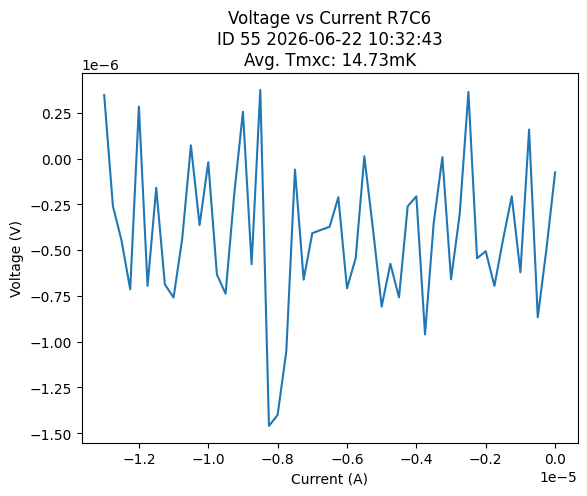

In [266]:
params.plot_critical_current(ID=55)

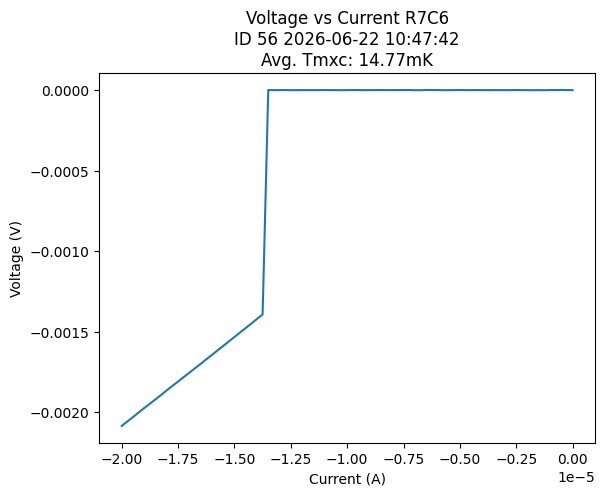

In [282]:
params.plot_critical_current(ID=56)

ID57: Trying laser on again to see if at lower temperature, the laser being on alters the transition current. Note that at the end of this sweep the mixing chamber reads 14.783mK (small increase)

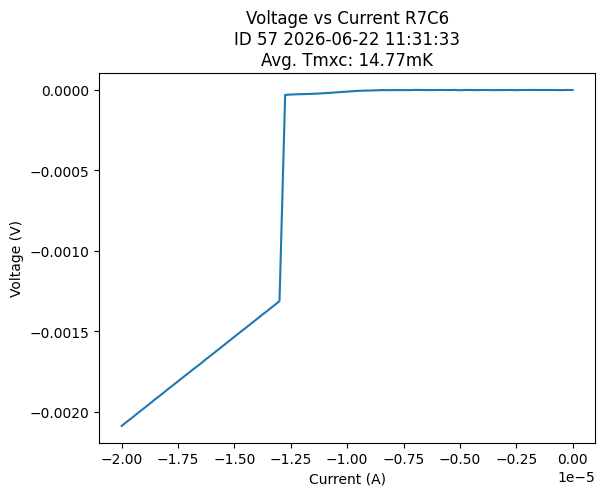

In [287]:
params.plot_critical_current(ID=57)

ID58: Trying amplifiers on again to see if at lower temperature, the amplifiers being on alters the transition current. (normal setings 5V for RT and 2.5V for 4K)

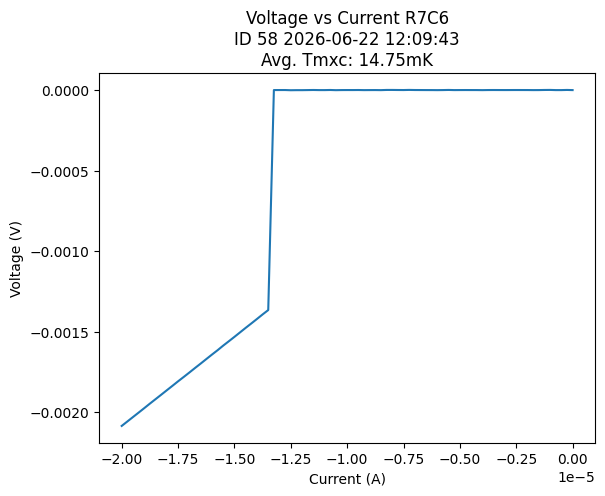

In [290]:
params.plot_critical_current(ID=58)

ID59: Then maybe swap the bias method one more time and run the sweep at similar temperature again to try to rule out the effect of temperature. 0.01mA drawn with 0V applied with yoko (on voltage mode) output ON but zero volt. Observed MXC temp went up to 14.718 at starting voltage -1.75V.
At -14.5V applied MXC reading is 14.756mK. MXC temp at beginning of sweep was 14.604mK. Visible increase on MXC theomometry - did the jump happen in the other sweep? 

([<Axes: title={'center': 'Run #59, Experiment SNSPD13_2026-06-15 (00)'}, xlabel='Voltage (V)', ylabel='Voltage (mV)'>],
 [None])

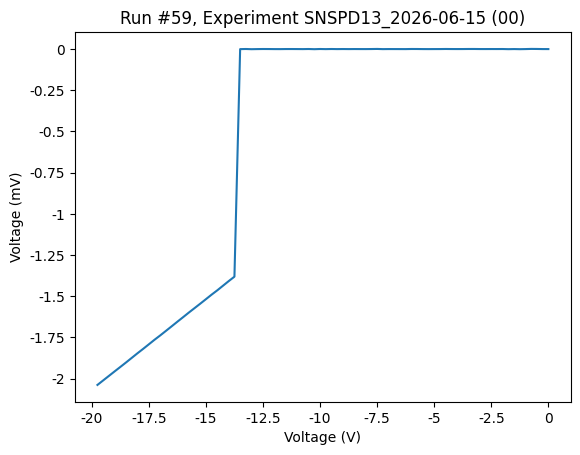

In [297]:
plot_by_id(59)

ID61: Both amplifiers on with current sourcing, laser off, 1V applied to 4K amplifier (draws 0.01A). 14.765mK. 

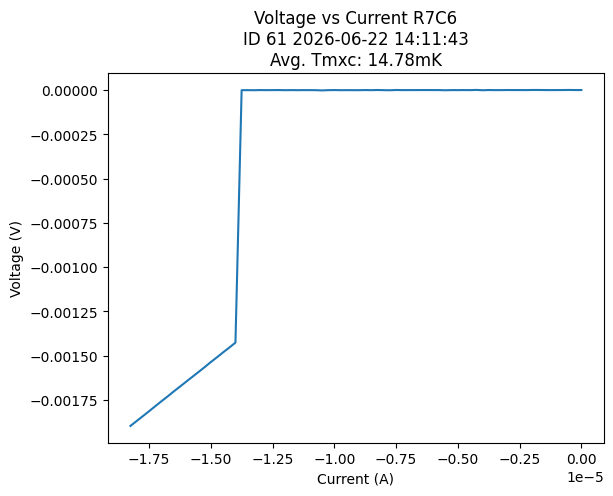

In [298]:
params.plot_critical_current(ID=61)

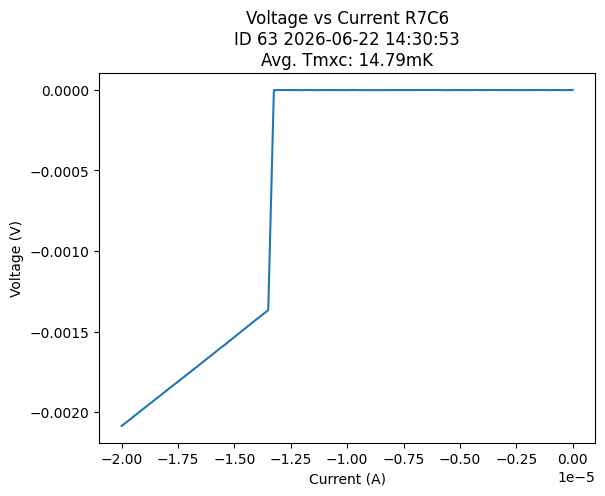

In [301]:
params.plot_critical_current(ID=63)

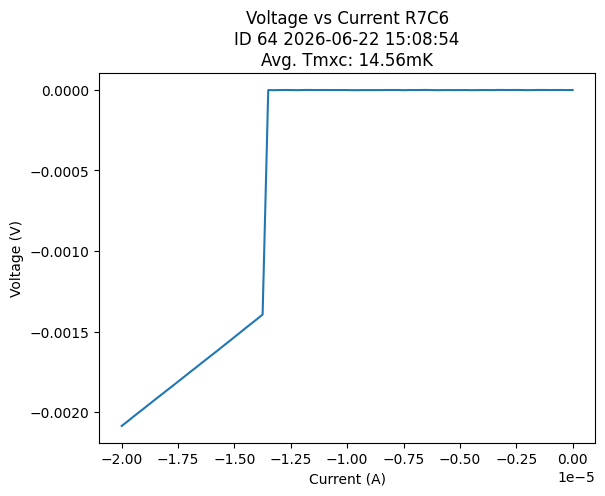

In [302]:
params.plot_critical_current(ID=64)

# Trace Plotting

Structure: 
* Extract trace and time axis based on ID routine for first way it was saved (by IDs). The structural output from this should be the traces and time axes as a list of lists. Other parameters for the 'list of IDs' structure should be saved as well, corresponding to the original list (this should be ok 
* 

In [ ]:
# if type(ID) is list: 
    # IDlist = ID
# elif type ID is not int: 
    # raise Exception()
def process_traces_IDs(IDlist, mult1, mult2):
    for ID in IDlist:
        data = load_by_id(ID).get_parameter_data()
        trace = data['trace']['trace']
        taxis = data['trace']['time_axis']
        current = data['yoko_current']['yoko_current'][~np.isnan(data['yoko_current']['yoko_current'])]
        trigger = data['trigger']['trigger'][0]
        plt.plot(taxis, trace)
        

In [ ]:
def process_traces(ID, mult1, mult2):
    from scipy.signal import find_peaks
    if (mult1 or mult2) > 1: 
        raise Exception('Multipliers must be between 1 and 0')
    data = load_by_id(ID).get_parameter_data()
    trace_raw = data['trace']['trace']
    time_axis_raw = data['time_axis']['time_axis']
    cols = int(data['h_samples']['h_samples'][0])
    voltage = data['yoko_voltage']['yoko_voltage'][~np.isnan(data['yoko_voltage']['yoko_voltage'])]
    v_peak = data['v_peak']['v_peak'][~np.isnan(data['v_peak']['v_peak'])]
    trigger = data['trigger']['trigger'][~np.isnan(data['trigger']['trigger'])]
    rows = len(voltage)
    trace = np.reshape(trace_raw, (rows, cols))
    time_axis = np.reshape(time_axis_raw, (rows, cols))
    threshold1 = v_peak*mult1
    threshold2 = v_peak*mult2
    return trace, time_axis, voltage, v_peak, trigger, threshold1, threshold2

In [ ]:
def plot_trace_interactive(self, ID):
    data = load_by_id(ID).get_parameter_data()
    ax, fig = plt.subplots()
    ax.plot()
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)